# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание. Нейронные сети

### Общая информация

Дата выдачи: 24.03.2026

Мягкий дедлайн: 14.04.2026 23:59

Жесткий дедлайн: 19.04.2026 23:59

### О задании

В этой работе две независимые части:

- Часть 1. Separable Physics-Informed Neural Network (SPINN) для решения 3D-уравнения Гельмгольца - 4 балла.

- Часть 2. CNN-классификация звуков на датасете UrbanSound8K - 6 баллов.

### Оценивание

Максимально допустимая оценка за работу - 10 баллов. 4 балла за SPINN и 6 баллов за CNN.

Задание выполняется самостоятельно. "Похожие" решения считаются плагиатом: все задействованные студенты (в том числе те, у кого списали) получают не более 0 баллов. Если вы использовали внешний источник (даже частично), укажите ссылку в отдельном блоке в конце работы.

Неэффективная реализация кода может негативно отразиться на оценке. Оценка также может быть снижена за плохо читаемый код и плохо оформленные диаграммы/таблицы. Изменять проверочные ячейки и пороги `assert` запрещено.

**Устная проверка.** Для проверки понимания кода и выводов студент может быть приглашён на устную защиту. Оценка за задание может быть изменена после устной защиты. Если студент не может объяснить ключевые части решения и принятые решения, работа считается недобросовестной и оценивается в 0 баллов независимо от автотестов.

### Про вычислительные ресурсы

Задание рассчитано на выполнение в бесплатном Google Colab или Kaggle Notebook, если реализация сделана разумно.

- Используйте GPU экономно: черновую отладку, проверку кода и подготовку пайплайна лучше сначала выполнять на CPU, а GPU подключать уже для обучения и финальных экспериментов. Это поможет избежать лишних проблем с памятью и не тратить ресурсы впустую.
- Для SPINN обучение должно занимать умеренное время; если одна конфигурация обучается слишком долго, стоит проверить размер модели, число коллокационных точек и эффективность реализации.
- Для UrbanSound8K рекомендуется предвычислять спектрограммы и сохранять их на диск. Без этого эксперименты часто упираются в CPU-препроцессинг, а не в обучение модели.
- Для подбора гиперпараметров разумно сначала работать на одном фиксированном dev-split, а полный 10-fold cross-validation запускать только для финальной модели.
- При обучении свёрточных сетей может помочь `torch.backends.cudnn.benchmark = True`.

### Формат сдачи

Задания сдаются через систему Anytask. Необходимо прислать ноутбук с выполненным заданием; к ноутбуку прикрепите два файла с весами лучших моделей для каждой из двух задач: `best_spinn_model.pth` и `best_cnn_model.pth`. Сам ноутбук называйте в формате `homework-practice-04-dl-Username.ipynb`, где Username - ваша фамилия.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку, исходя из набора выполненных задач и достигнутого качества, и укажите её ниже.

Оценка: ...






In [50]:
import torch
import torchaudio
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

from typing import Tuple, List
from tqdm.auto import tqdm, trange
from IPython import display

import librosa
import librosa.display
from IPython.display import Audio

## Часть 2. Классификация звуков UrbanSound8K с помощью CNN (6 баллов)


### Разбалловка

Во второй части нужно пройти весь стандартный пайплайн аудиоклассификации: подготовить данные, реализовать модель, обучить её и провести итоговую оценку.

| Подзадача | Баллы | Что оценивается |
|-----------|-------|-----------------|
| 2.1 Подготовка данных и Dataset | **1,0** | Корректный fold-aware pipeline, реализация `UrbanSoundDataset`, аккуратная работа с метками |
| 2.2 Архитектура CNN | **1,0** | Рабочая сверточная модель для классификации мел-спектрограмм |
| 2.3 Обучение и валидация | **1,0** | Реализация train/validate, early stopping, осмысленная настройка обучения |
| 2.4 Качество модели | **2,5** | Итоговое качество по accuracy |
| 2.5 Краткий анализ | **0,5** | Наблюдения по архитектуре, аугментациям, ошибкам модели и качеству |

> В этой части важно не только получить хороший score, но и корректно организовать эксперимент. Использование правильного протокола разбиения данных здесь является частью задания, а не технической деталью.

### Введение в обработку аудио

#### Почему не всегда удобно работать с сырым аудиосигналом?

Аудиосигнал - это последовательность амплитудных отсчётов во времени. Например, 4-секундный фрагмент при частоте дискретизации 22 050 Гц содержит около 88 тысяч значений. Теоретически такие данные можно подавать напрямую в нейросеть, но на практике это не самый удобный вариант:

1. **Высокая размерность.** Даже короткий сигнал содержит много отсчётов.
2. **Сложная временная структура.** В сигнале одновременно важны и короткие локальные паттерны, и более длинные зависимости.
3. **Частотная информация скрыта неявно.** По самому временному ряду не так удобно понять, какие частоты присутствуют в сигнале.

**Спектрограммы**

Это представление сигнала в плоскости "время–частота". Она строится с помощью кратковременного преобразования Фурье (STFT): сигнал разбивается на короткие окна, для каждого окна вычисляется частотный спектр, после чего эти спектры собираются по времени.

В результате получается 2D-представление, где:
- по оси X идёт время;
- по оси Y - частота;
- цвет отражает энергию сигнала на данной частоте в данный момент.

**Мел-спектрограмма**

Обычная спектрограмма полезна, но не полностью соответствует тому, как человек воспринимает звук. Поэтому в задачах аудиоклассификации часто используют мел-спектрограммы.

Идея здесь в том, что:
- частоты переводятся в мел-шкалу, которая лучше соответствует человеческому слуху;
- амплитуды обычно переводятся в децибельную шкалу, то есть в логарифмический масштаб.

Мел-спектрограммы удобны по нескольким причинам:
1. уменьшают размерность;
2. сохраняют наиболее важную перцептивную информацию;
3. дают 2D-представление, с которым удобно работать при помощи CNN.

Именно поэтому в этой части домашнего задания мы будем классифицировать не сырые аудиосигналы, а именно - мел-спектрограммы.

![Пример мел-спектрограммы](https://manual.audacityteam.org/m/images/e/ed/mel_log_linear_spectrogram_annotated.png)

*Пример мел-спектрограммы: ось X - время, ось Y - частота по мел-шкале, цвет отражает амплитуду (от тёмных = низкая энергия до ярких = высокая энергия)*

Источники - [курс DLA](https://github.com/markovka17/dla), [audacity](https://manual.audacityteam.org/man/spectrogram_view.html)

### UrbanSound8K

Мы будем работать с датасетом **UrbanSound8K**. В нём содержится 8732 размеченных аудиофрагмента городских звуков длительностью не более 4 секунд. В датасете 10 классов:
`air_conditioner`, `car_horn`, `children_playing`, `dog_bark`, `drilling`, `engine_idling`, `gun_shot`, `jackhammer`, `siren`, `street_music`.

Скачиваем UrbanSound8K отсюда https://urbansounddataset.weebly.com/urbansound8k.html

Структура датасета:
```
UrbanSound8K/
├── audio/
│   ├── fold1/
│   ├── fold2/
│   └── ...
└── metadata/
    └── UrbanSound8K.csv
```

**Важное замечание про протокол разбиения**

UrbanSound8K уже разбит авторами на 10 fold'ов, и в этой задаче нужно использовать именно их.

Для этого датасета не стоит делать случайное разбиение, потому что фрагменты, относящиеся к одному и тому же исходному событию, могут оказаться и в обучении, и в тесте. В таком случае качество будет завышено и перестанет честно отражать способность модели обобщать на новые данные.

Поэтому здесь используется следующая схема:

- для быстрых экспериментов: `folds 1–8 -> train`, `9 -> val`, `10 -> test`;
- для финальной оценки: один прогон 10-fold cross-validation по official folds.

Случайно перераспределять примеры между fold'ами не нужно.  
При этом `shuffle=True` внутри `train_loader` использовать можно.

In [51]:
DATASET_PATH = "/kaggle/input/datasets/sashatereshko/urbansound8k-tar-gz/UrbanSound8K"

# Загрузим метаданные
metadata = pd.read_csv(os.path.join(DATASET_PATH, "metadata", "UrbanSound8K.csv"))

print(f"Всего примеров: {len(metadata)}")
print("\nРаспределение по классам:")
print(metadata["class"].value_counts().sort_index())
print("\nРаспределение по fold'ам:")
print(metadata["fold"].value_counts().sort_index())

Всего примеров: 8732

Распределение по классам:
class
air_conditioner     1000
car_horn             429
children_playing    1000
dog_bark            1000
drilling            1000
engine_idling       1000
gun_shot             374
jackhammer          1000
siren                929
street_music        1000
Name: count, dtype: int64

Распределение по fold'ам:
fold
1     873
2     888
3     925
4     990
5     936
6     823
7     838
8     806
9     816
10    837
Name: count, dtype: int64


Сначала посмотрим, как выглядят один и тот же аудиофрагмент в виде волновой формы, обычной спектрограммы и мел-спектрограммы.

Sample: 194910-9-0-65.wav
Class: street_music
Fold: 5



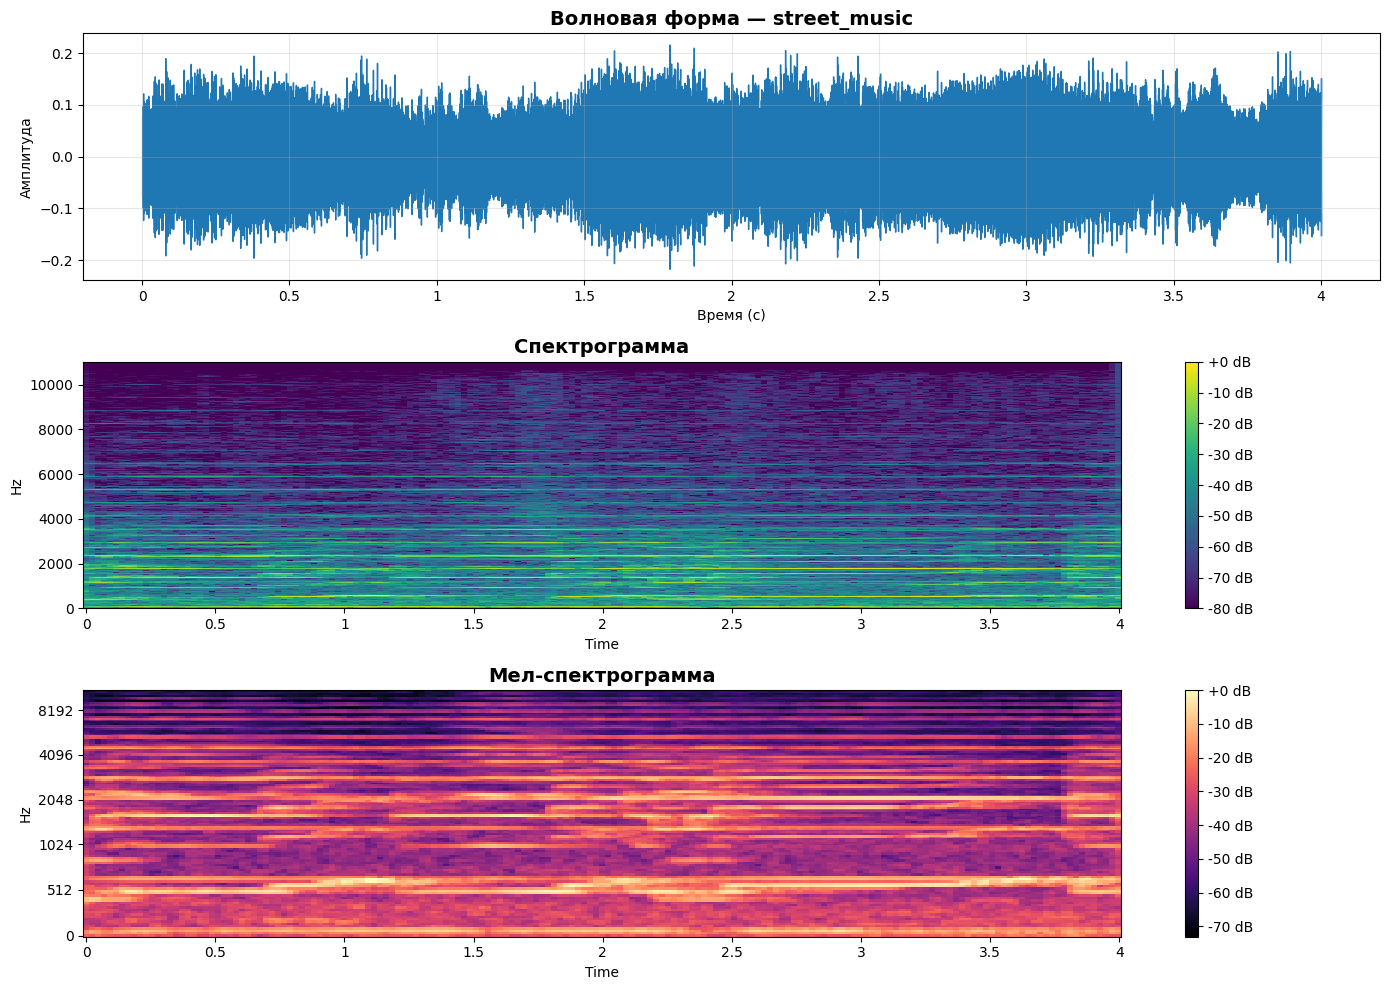

In [52]:
def plot_waveform_and_spectrogram(audio_path, class_name):
    y, sr = librosa.load(audio_path, sr=22050)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title(f"Волновая форма — {class_name}", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Время (с)")
    axes[0].set_ylabel("Амплитуда")
    axes[0].grid(alpha=0.3)

    D = librosa.stft(y)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    img1 = librosa.display.specshow(
        S_db, sr=sr, x_axis="time", y_axis="hz", ax=axes[1], cmap="viridis"
    )
    axes[1].set_title("Спектрограмма", fontsize=14, fontweight="bold")
    fig.colorbar(img1, ax=axes[1], format="%+2.0f dB")

    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    img2 = librosa.display.specshow(
        mel_spec_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[2], cmap="magma"
    )
    axes[2].set_title("Мел-спектрограмма", fontsize=14, fontweight="bold")
    fig.colorbar(img2, ax=axes[2], format="%+2.0f dB")

    plt.tight_layout()
    plt.show()
    return y, sr


random_idx = np.random.randint(0, len(metadata))
sample = metadata.iloc[random_idx]

audio_path = os.path.join(DATASET_PATH, "audio", f"fold{sample.fold}", sample.slice_file_name)
print(f"Sample: {sample.slice_file_name}")
print(f"Class: {sample['class']}")
print(f"Fold: {sample.fold}\n")

y, sr = plot_waveform_and_spectrogram(audio_path, sample["class"])
Audio(y, rate=sr)

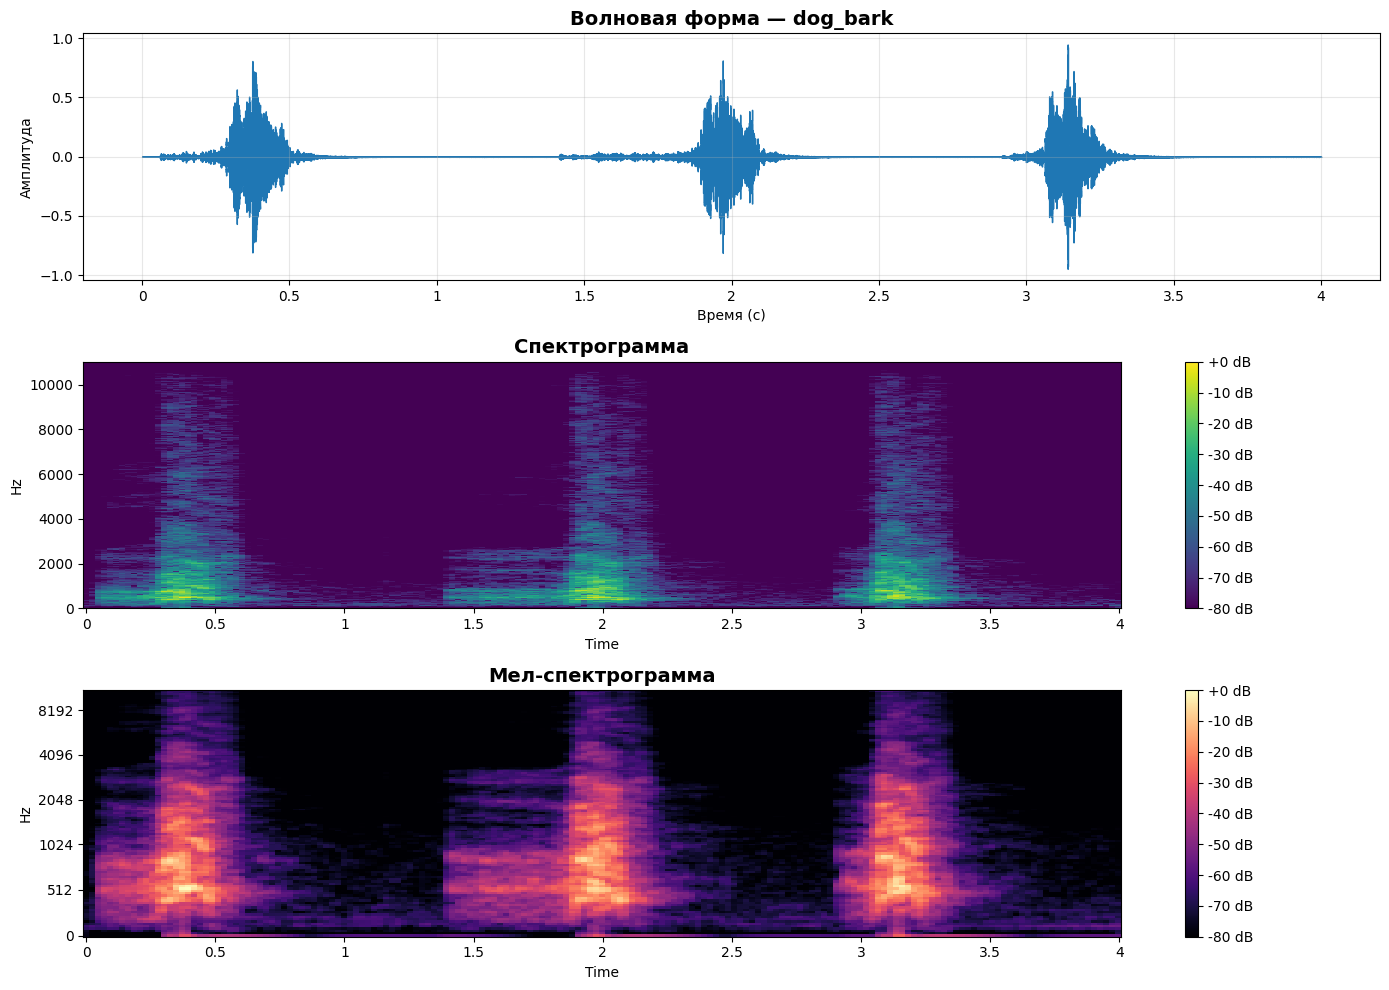

In [53]:
target_class = 'dog_bark'

class_samples = metadata[metadata['class'] == target_class]
sample = class_samples.sample(1).iloc[0]

audio_path = os.path.join(DATASET_PATH, 'audio', f'fold{sample.fold}', sample.slice_file_name)
y, sr = plot_waveform_and_spectrogram(audio_path, target_class)

Audio(y, rate=sr)

### Задание 2.1. Подготовьте датасет к обучению модели (1 балл)

В этой части нужно реализовать `UrbanSoundDataset`.

Несколько важных условий:

- используйте официальные fold'ы;
- не делайте `fit` для `LabelEncoder` отдельно на каждом split;
- не извлекайте мел-спектрограммы заново при каждом обращении к `__getitem__`, если этого можно избежать.

**Последний пункт особенно важен.** Извлечение спектрограмм через `librosa` - CPU-bound операция, и если делать её на лету для каждого батча, обучение быстро начинает тормозить не из-за модели, а из-за препроцессинга. Поэтому в этой задаче рекомендуется один раз подготовить спектрограммы и либо держать их в памяти, либо кэшировать на диск.

Идея простая: `__getitem__` должен быть как можно легче. В идеале там уже не должно происходить ничего дорогого, кроме извлечения готового тензора и, при необходимости, несложной аугментации.

In [54]:
# Единый LabelEncoder

ALL_CLASSES = sorted(metadata["class"].unique())
global_label_encoder = LabelEncoder()
global_label_encoder.fit(ALL_CLASSES)

print(f"Классы ({len(global_label_encoder.classes_)}):")
print(list(global_label_encoder.classes_))

Классы (10):
[np.str_('air_conditioner'), np.str_('car_horn'), np.str_('children_playing'), np.str_('dog_bark'), np.str_('drilling'), np.str_('engine_idling'), np.str_('gun_shot'), np.str_('jackhammer'), np.str_('siren'), np.str_('street_music')]


In [55]:
metadata

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.000000,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.500000,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.500000,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.000000,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.500000,72.500000,1,5,2,children_playing
...,...,...,...,...,...,...,...,...
8727,99812-1-2-0.wav,99812,159.522205,163.522205,2,7,1,car_horn
8728,99812-1-3-0.wav,99812,181.142431,183.284976,2,7,1,car_horn
8729,99812-1-4-0.wav,99812,242.691902,246.197885,2,7,1,car_horn
8730,99812-1-5-0.wav,99812,253.209850,255.741948,2,7,1,car_horn


In [ ]:
class UrbanSoundDataset(Dataset):
    def __init__(
        self,
        metadata,
        dataset_path,
        label_encoder,
        target_length=4,
        sr=22050,
        n_mels=128,
        augment=False,
        cache_dir=None, 
    ):
        self.metadata = metadata.reset_index(drop=True)
        self.dataset_path = dataset_path
        self.label_encoder = label_encoder
        self.target_length = target_length
        self.sr = sr
        self.n_mels = n_mels
        self.augment = augment
        self.cache_dir = cache_dir
        self.target_s = int(self.target_length * self.sr)
        


        
        if self.cache_dir:
            os.makedirs(self.cache_dir, exist_ok=True)
        
        # Предварительно вычисляем все спектрограммы
        self.mels = []
        self.labels = []
        self._prepare_data()
    
    def _prepare_data(self):
        """кеширование"""
        # эту функцию я делал совместно с чатом, основной промт был: объяснить и показать как лучше кешировать выборку в торче
        for idx in range(len(self.metadata)):
            # Проверяем кэш на диске
            cache_path = None
            if self.cache_dir:
                cache_path = os.path.join(self.cache_dir, f"{idx}.pt")
                if os.path.exists(cache_path):
                    mel = torch.load(cache_path)
                    self.mels.append(mel)
                    label = self.label_encoder.transform([self.metadata.iloc[idx]['class']])[0]
                    self.labels.append(label)
                    continue
            
            # Вычисляем спектрограмму
            file_path = os.path.join(self.dataset_path, self.metadata.iloc[idx]['slice_file_name'])
            y = self._load_audio(file_path)
            mel = self._extract_mel_spectrogram(y)
            mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
            
            # Сохраняем в кэш
            if cache_path:
                torch.save(mel, cache_path)
            
            self.mels.append(mel)
            label = self.label_encoder.transform([self.metadata.iloc[idx]['class']])[0]
            self.labels.append(label)
        
        self.labels = torch.tensor(self.labels, dtype=torch.long)
    
    def _load_audio(self, file_path):
        zvuk, _ = librosa.load(file_path, sr=self.sr)
        if len(zvuk) < self.target_s:
            zvuk = np.pad(zvuk, (0, self.target_s - len(zvuk)), mode="constant")
        else:
            zvuk = zvuk[:self.target_s]
        return zvuk
    
    def _extract_mel_spectrogram(self, y):
        mel = librosa.feature.melspectrogram(y=y, sr=self.sr, n_mels=self.n_mels, n_fft=2048, hop_length=512, power=2.0)
        mel = librosa.power_to_db(mel, ref=np.max)
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)
        return mel
    
    def __len__(self):
        return len(self.metadata)
    

    def augment_audio(self, y):
        """разные аугментации, которые удалось придумать"""
        y = y.clone()

        if np.random.rand() < 0.5:
            # шууууум
            y = y + torch.randn_like(y) * 0.01

        if np.random.rand() < 0.5:
            """зануляем какие-то частоты"""
            f = y.shape[1]
            rand_freq = np.random.randint(3, 10)
            if f > rand_freq:
                start = np.random.randint(0, f - rand_freq)
                y[:, start:start + rand_freq, :] = 0

        if np.random.rand() < 0.5:
            """изменение ГРОМКОСТИ"""
            scale = np.random.uniform(0.9, 1.1)
            y = y * scale

        if np.random.rand() < 0.5:
            """сдвиг по времени, если это можно так назвать"""
            shift = np.random.randint(-3, 4)
            y = torch.roll(y, shifts=shift, dims=2)

        return y
    
    def __getitem__(self, idx):
        mel = self.mels[idx].clone()
        label = self.labels[idx]
        
        if self.augment:
            mel = self.augment_audio(mel)
        
        return mel, label



#### Dev-split для быстрых экспериментов

In [57]:
def get_fold_split(metadata, test_fold, val_fold=None):
    """
    Разбиение по official folds.

    Если val_fold задан:
        train = все fold'ы, кроме test_fold и val_fold
        val   = val_fold
        test  = test_fold

    Если val_fold не задан:
        train = все fold'ы, кроме test_fold
        test  = test_fold
    """
    test_df = metadata[metadata["fold"] == test_fold]

    if val_fold is not None:
        assert val_fold != test_fold
        val_df = metadata[metadata["fold"] == val_fold]
        train_folds = [f for f in range(1, 11) if f not in {test_fold, val_fold}]
    else:
        val_df = None
        train_folds = [f for f in range(1, 11) if f != test_fold]

    train_df = metadata[metadata["fold"].isin(train_folds)]

    print(
        f"test={test_fold}"
        + (f", val={val_fold}" if val_fold is not None else "")
        + f" | Train: {len(train_df)}, Val: {len(val_df) if val_df is not None else 0}, Test: {len(test_df)}"
    )
    return train_df, val_df, test_df

Для подбора архитектуры и отладки удобно сначала работать на одном фиксированном разбиении:
- `train = folds 1–8`
- `val = fold 9`
- `test = fold 10`

Финальную 10-fold оценку лучше запускать уже после того, как основная конфигурация выбрана.

In [58]:
train_df, val_df, test_df = get_fold_split(metadata, test_fold=10, val_fold=9)

BATCH_SIZE = 64

train_dataset = UrbanSoundDataset(
    train_df,
    DATASET_PATH,
    global_label_encoder,
    augment=True,
)

val_dataset = UrbanSoundDataset(
    val_df,
    DATASET_PATH,
    global_label_encoder,
    augment=False,
)

test_dataset = UrbanSoundDataset(
    test_df,
    DATASET_PATH,
    global_label_encoder,
    augment=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

sample_batch, sample_labels = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")
print(f"Labels shape: {sample_labels.shape}")
print(f"First labels: {sample_labels[:5]}")

test=10, val=9 | Train: 7079, Val: 816, Test: 837
Batch shape: torch.Size([64, 1, 128, 173])
Labels shape: torch.Size([64])
First labels: tensor([6, 0, 0, 8, 5])


### Задание 2.2. Реализуйте вашу архитектуру (1 балл)

В этой задаче разрешены только **свёрточные архитектуры**.

Нельзя использовать:
- RNN;
- LSTM / GRU;
- Transformer.

Можно использовать: обычные CNN-блоки, batch normalization, dropout,pooling, при желании - несложные attention-модули поверх CNN, если основа модели всё равно остаётся сверточной.

На вход модель получает мел-спектрограмму формы `(B, 1, n_mels, time)`, а на выходе должна возвращать логиты по 10 классам.

In [ ]:
class UrbanSoundCNN(nn.Module):
    """что-то типа Resnet"""
    def __init__(self, num_classes=10, dropout=0.4, fc_dim=128):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        self.layer1 = ResidualBlock(32, 32, stride=1)
        self.layer2 = ResidualBlock(32, 64, stride=2)
        self.layer3 = ResidualBlock(64, 128, stride=2)
        self.layer4 = ResidualBlock(128, 256, stride=2)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.final = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, fc_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_dim, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.global_pool(x)
        x = self.final(x)

        return x

class ResidualBlock(nn.Module):
    """блок в реснете со своим числом сверток"""
    def __init__(self, in_channels, out_channels, stride):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            # тут мы подбираем размерность
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        x = x + identity
        x = self.relu(x)

        return x


def init_weights(m):
    """инициализация весов"""
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

    elif isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0, 0.01)
        nn.init.constant_(m.bias, 0)

### Задание 2.3. Реализуйте обучение и валидацию модели (1 балл)

Теперь нужно написать код обучения модели на dev-split.

Ожидается, что у вас будут:
- функция `train_epoch`;
- функция `validate`;
- цикл обучения с early stopping;
- сохранение лучшей модели по качеству на валидации.

Здесь нет единственно правильной реализации, но ваш код должен быть аккуратным, воспроизводимым и согласованным с поставленной задачей.

In [60]:
device = "cuda"

In [61]:
def train_epoch(model, loader, criterion, optimizer, device):
    # -> (loss, acc)
    model.train()
    total_loss = 0
    total_correct = 0
    total_count = 0

    for batch, y_true in loader:
        batch = batch.to(device)
        y_true = y_true.to(device)

        optimizer.zero_grad()

        y_pred = model(batch)
        loss = criterion(y_pred, y_true)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.size(0)

        y_pred_class = y_pred.argmax(dim=1)
        total_correct += (y_pred_class == y_true).sum().item()
        total_count += batch.size(0)

    epoch_loss = total_loss / total_count
    epoch_acc = total_correct / total_count

    return epoch_loss, epoch_acc

        
    
def validate(model, loader, criterion, device):
    # -> (loss, acc)
    model.eval()
    total_loss = 0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for batch, y_true in loader:
            batch = batch.to(device)
            y_true = y_true.to(device)

            y_pred = model(batch)
            loss = criterion(y_pred, y_true)

            total_loss += loss.item() * batch.size(0)

            y_pred_class = y_pred.argmax(dim=1)
            total_correct += (y_pred_class == y_true).sum().item()
            total_count += batch.size(0)

    epoch_loss = total_loss / total_count
    epoch_acc = total_correct / total_count

    return epoch_loss, epoch_acc
    

model = UrbanSoundCNN().to(device)
model.apply(init_weights)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("\nModel:")
print(model)

Total parameters: 11,175,370
Trainable parameters: 11,175,370

Model:
UrbanSoundCNN(
  (stem): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=Fals

In [62]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

NUM_EPOCHS = 50
PATIENCE = 15

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = 0.0
patience_counter = 0


for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )

    val_loss, val_acc = validate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch [{epoch}/{NUM_EPOCHS}] | "
        f"lr={current_lr:.6f} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
    )

Epoch [1/50] | lr=0.001000 | train_loss=1.1988 | train_acc=0.5737 | val_loss=1.2986 | val_acc=0.5858
Epoch [2/50] | lr=0.001000 | train_loss=0.6747 | train_acc=0.7768 | val_loss=1.3235 | val_acc=0.6973
Epoch [3/50] | lr=0.001000 | train_loss=0.4998 | train_acc=0.8342 | val_loss=1.0633 | val_acc=0.7169
Epoch [4/50] | lr=0.001000 | train_loss=0.3734 | train_acc=0.8785 | val_loss=1.4230 | val_acc=0.6569
Epoch [5/50] | lr=0.001000 | train_loss=0.2964 | train_acc=0.9054 | val_loss=1.2082 | val_acc=0.7255
Epoch [6/50] | lr=0.001000 | train_loss=0.2700 | train_acc=0.9124 | val_loss=1.3221 | val_acc=0.7181
Epoch [7/50] | lr=0.000500 | train_loss=0.2134 | train_acc=0.9315 | val_loss=1.4814 | val_acc=0.6814
Epoch [8/50] | lr=0.000500 | train_loss=0.1244 | train_acc=0.9621 | val_loss=1.3406 | val_acc=0.7439
Epoch [9/50] | lr=0.000500 | train_loss=0.0908 | train_acc=0.9679 | val_loss=1.3088 | val_acc=0.7365
Epoch [10/50] | lr=0.000500 | train_loss=0.0778 | train_acc=0.9751 | val_loss=1.5456 | val_

После обучения оцените модель на test-части dev-split. Затем постройте confusion matrix и посмотрите, какие классы модель путает чаще всего.

In [63]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test accuracy on dev-split: {test_acc * 100:.2f}%")
# model.load_state_dict(torch.load("best_cnn_model.pth", map_location=device))


Testing:   0%|          | 0/14 [00:00<?, ?it/s]

Test accuracy on dev-split: 76.70%


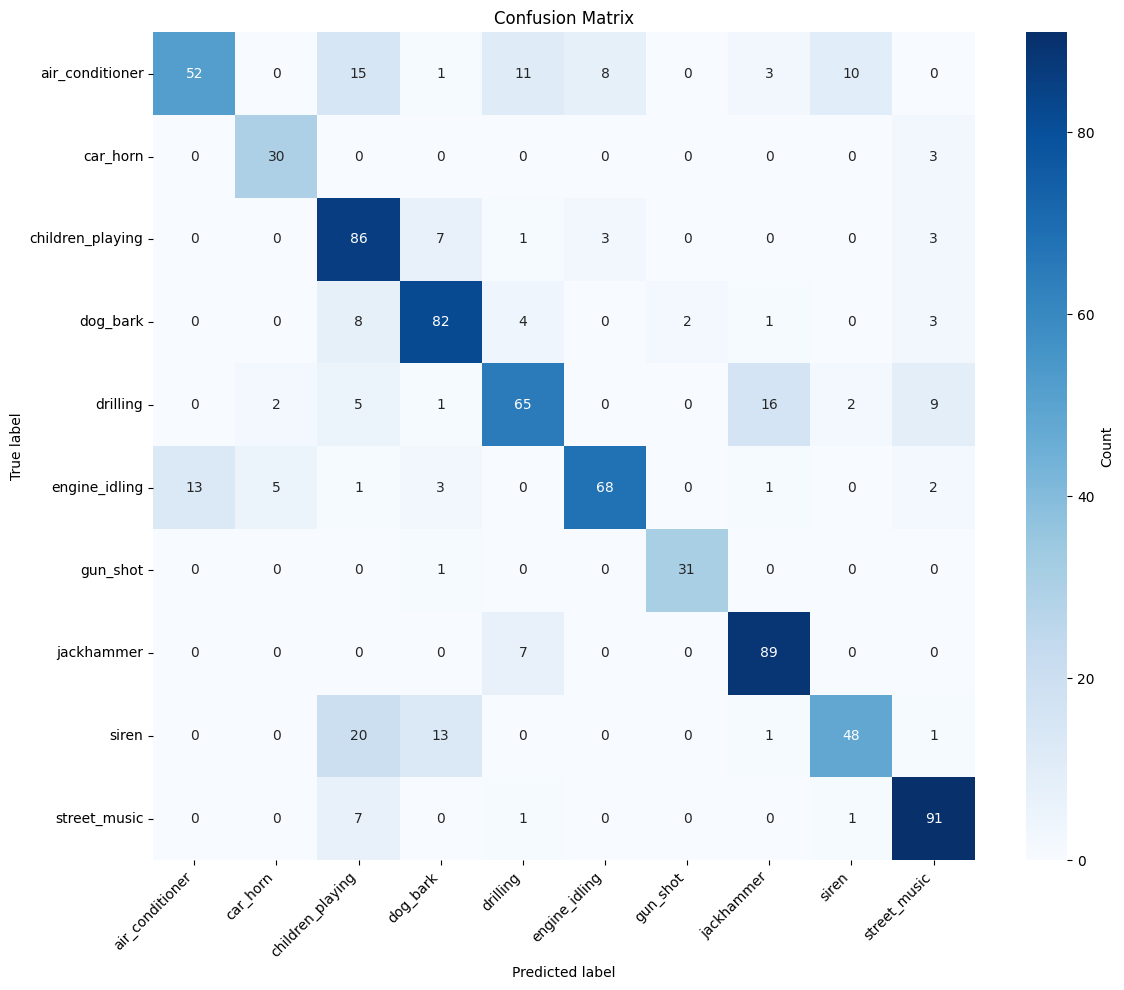

                  precision    recall  f1-score   support

 air_conditioner     0.8000    0.5200    0.6303       100
        car_horn     0.8108    0.9091    0.8571        33
children_playing     0.6056    0.8600    0.7107       100
        dog_bark     0.7593    0.8200    0.7885       100
        drilling     0.7303    0.6500    0.6878       100
   engine_idling     0.8608    0.7312    0.7907        93
        gun_shot     0.9394    0.9688    0.9538        32
      jackhammer     0.8018    0.9271    0.8599        96
           siren     0.7869    0.5783    0.6667        83
    street_music     0.8125    0.9100    0.8585       100

        accuracy                         0.7670       837
       macro avg     0.7907    0.7874    0.7804       837
    weighted avg     0.7765    0.7670    0.7620       837



In [64]:
cm = confusion_matrix(all_labels, all_preds)
class_names = global_label_encoder.classes_

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={"label": "Count"},
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

### Задание 2.4. Финальная 10-fold оценка (2,5 балла)

После того как вы подобрали рабочую конфигурацию на dev-split, проведите один финальный прогон 10-fold cross-validation.

Для каждого `test_fold`:
- `val_fold` берётся как следующий fold по кругу;
- все остальные fold'ы идут в train.

Итоговое качество считается по средней accuracy по всем 10 fold'ам.

In [65]:
def evaluate_10fold(
    model_class,
    model_kwargs,
    train_fn,
    metadata,
    dataset_path,
    label_encoder,
    device="cuda",
    verbose=True,
):
    """
    10-fold CV по folds UrbanSound8K
    """
    accuracies = []

    for test_fold in range(1, 11):
        val_fold = 1 if test_fold == 10 else test_fold + 1
        train_folds = [f for f in range(1, 11) if f not in {test_fold, val_fold}]

        if verbose:
            print(f"\n{'=' * 50}")
            print(f"Fold {test_fold}/10 (val={val_fold}, train={train_folds})")

        train_df = metadata[metadata["fold"].isin(train_folds)]
        val_df = metadata[metadata["fold"] == val_fold]
        test_df = metadata[metadata["fold"] == test_fold]

        train_ds = UrbanSoundDataset(train_df, dataset_path, label_encoder, augment=True)
        val_ds = UrbanSoundDataset(val_df, dataset_path, label_encoder, augment=False)
        test_ds = UrbanSoundDataset(test_df, dataset_path, label_encoder, augment=False)

        loader_kwargs = dict(num_workers=4, pin_memory=True)
        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, **loader_kwargs)
        val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, **loader_kwargs)
        test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, **loader_kwargs)

        model = model_class(**model_kwargs).to(device)
        model = train_fn(model, train_loader, val_loader, device)

        model.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                preds = model(inputs).argmax(1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        acc = np.mean(np.array(all_preds) == np.array(all_labels))
        accuracies.append(acc)

        if verbose:
            print(f"Fold {test_fold} accuracy: {acc * 100:.2f}%")

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)

    if verbose:
        print(f"\n{'=' * 50}")
        print(f"10-fold CV: {mean_acc * 100:.2f}% ± {std_acc * 100:.2f}%")

    return accuracies

In [82]:
def my_train_fn(model, train_loader, val_loader, device):
    """
    Оберните свой training loop в функцию.
    Она должна вернуть обученную модель.
    """
    mpdel = model.to(device)
    model.apply(init_weights)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
    )

    num_epochs = 20
    patience = 7
    patience_counter = 0
    best_val_acc = 0.0
    best_model_path = "best_model.pth"

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
        else:
            patience_counter += 1

        

    model.load_state_dict(torch.load(best_model_path, map_location=device))
    return model

In [83]:
accuracies = evaluate_10fold(
    model_class=UrbanSoundCNN,
    model_kwargs={"num_classes": 10},
    train_fn=my_train_fn,
    metadata=metadata,
    dataset_path=DATASET_PATH,
    label_encoder=global_label_encoder,
    device=device,
)


Fold 1/10 (val=2, train=[3, 4, 5, 6, 7, 8, 9, 10])
Epoch 1/20 | train_loss=1.3259 | train_acc=0.5336 | val_loss=1.3596 | val_acc=0.4899
Epoch 2/20 | train_loss=0.7784 | train_acc=0.7369 | val_loss=1.9885 | val_acc=0.5709
Epoch 3/20 | train_loss=0.5408 | train_acc=0.8197 | val_loss=1.2104 | val_acc=0.6791
Epoch 4/20 | train_loss=0.3857 | train_acc=0.8755 | val_loss=0.9774 | val_acc=0.6959
Epoch 5/20 | train_loss=0.3479 | train_acc=0.8861 | val_loss=1.2685 | val_acc=0.6509
Epoch 6/20 | train_loss=0.2703 | train_acc=0.9095 | val_loss=1.5590 | val_acc=0.6070
Epoch 7/20 | train_loss=0.2623 | train_acc=0.9086 | val_loss=1.7106 | val_acc=0.6419
Epoch 8/20 | train_loss=0.2173 | train_acc=0.9267 | val_loss=1.4223 | val_acc=0.6025
Epoch 9/20 | train_loss=0.1216 | train_acc=0.9611 | val_loss=1.0383 | val_acc=0.7309
Epoch 10/20 | train_loss=0.0798 | train_acc=0.9742 | val_loss=0.9992 | val_acc=0.7072
Epoch 11/20 | train_loss=0.0771 | train_acc=0.9766 | val_loss=1.6110 | val_acc=0.6408
Epoch 12/20

In [87]:
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)

for i, acc in enumerate(accuracies, 1):
    print(f"Fold {i}: {acc * 100:.2f}%")

print(f"\n10-fold CV: {mean_acc * 100:.2f}% ± {std_acc * 100:.2f}%")

Fold 1: 62.89%
Fold 2: 66.33%
Fold 3: 64.54%
Fold 4: 70.00%
Fold 5: 79.06%
Fold 6: 69.99%
Fold 7: 69.45%
Fold 8: 71.71%
Fold 9: 75.49%
Fold 10: 73.00%

10-fold CV: 70.25% ± 4.67%


Баллы за пункт 2.4 начисляются в зависимости от лучшего выполненного порога по средней accuracy в 10-fold CV: чем выше итоговое качество, тем больше доля из 2,5 балла за эту часть.

In [89]:
score_2_4 = 0.0

if mean_acc >= 0.64:
    score_2_4 = 0.5 * 2.5
if mean_acc >= 0.69:
    score_2_4 = 0.6 * 2.5
if mean_acc >= 0.74:
    score_2_4 = 0.7 * 2.5
if mean_acc >= 0.79:
    score_2_4 = 0.8 * 2.5
if mean_acc >= 0.84:
    score_2_4 = 0.9 * 2.5
if mean_acc >= 0.88:
    score_2_4 = 1.0 * 2.5

print(f"Mean CV accuracy: {mean_acc:.4f}")
print(f"Баллы за пункт 2.4: {score_2_4:.2f} / 2.5")

Mean CV accuracy: 0.7025
Баллы за пункт 2.4: 1.50 / 2.5


### Задание 2.5. Краткий анализ (0,5 балла)

В конце прокомментируйте свою работу:

1. Какую архитектуру вы выбрали и почему.
2. Какие аугментации оказались полезными, а какие нет.
3. Что сильнее влияло на качество: сама CNN, preprocessing или параметры обучения.
4. Какие классы модель путала чаще всего и почему это выглядит правдоподобно.
5. Насколько различались результаты между fold'ами.


`Анализ: # your text here (ಠ.ಠ)`
1. Сначала я писал простенькую архитектуру, а потом дошло, что в целом можно обратиться в секретные знания полученные на лекции и написать совй реснет, что я и сделал, может быть криво, но в целом я доволен результатом
2. Я пользовался всем, что в голову пришло и что сказал чат, подобрал к ним оптимальные параметры и на мой взгляд лучшие: Шум - что-то типа регулязации,  рандомное зануление звука, сдвиги и еще то, что у меня реализовано
3. Больше всего мне помогла архитектура и подбор параметров
4. children_playing и dog_bark, так как оба класса содержат прерывистые, ритмичные высокочастотные звуки — лай собаки и детские крики.  jackhammer и drilling, так как оба — это ударные строительные шумы с похожим низкочастотным треском и боем
5. не особо различались, первые фолды были чуть похуже по сравнению с остальными 